# Modern Pipeline - Complete Workflow

This notebook demonstrates the **modern approach** to data processing using the complete toolkit.

**One command instead of manual processing for each dataset!**

# Table of Contents
1. [Part 1: Complete Modern Pipeline (One Command!)](#Part-1:-Process-All-Datasets)
2. [Part 2: Data Quality Report](#Part-2:-Data-Quality-Report)
3. [Part 3: Summary Statistics](#Part-3:-Summary-Statistics:-Describing-the-Data)
4. [Part 4: Augmented Dickey-Fuller Stationarity Tests](#Part-4:-Stationarity-Tests:-A-Critical-Assumption-for-Time-Series)
5. [Part 5: Create Lags and Check Panel Balance](#Part-5:-Creating-Lag-Variables-for-Dynamic-Models)
6. [Part 6: Visualisation and Descriptive Analysis](#Part-6:-Exploratory-Visualisation)
7. [Part 7: Main Regression Analysis (Levels and Interacted)](#Part-7:-Heterogeneity-Regressions)
    - [Baseline Regressions: The Average Effect](#Baseline-Regressions:-The-Average-Effect-of-Globalisation)
    - [Welfare Regime Interactions: Heterogeneity Analysis](#Panel-Fixed-Effects-Regression-with-Welfare-Regime-Interactions)
    - [Robustness Checks: Sensitivity Analysis](#Robustness-Checks:-Testing-the-Stability-of-Our-Results)
8. [Part 8: Feedback Regressions (Reverse Causality)](#Part-8:-Feedback-Regressions)
9. [Part 9: Export to R / Stata](#Part-9:-Exporting-for-Other-Statistical-Software)


## Setup

## Setup: Configuring the Project Environment

Before any analysis can begin, we need to tell Python where our custom source code lives.

The cell below performs two critical tasks:
1. **Sets the repository root** — Using `pathlib.Path`, we establish an absolute reference point (`REPO_ROOT`) so all file paths (data, outputs) are portable and reproducible regardless of where the notebook is opened from.
2. **Adds `src/` to `sys.path`** — Our reusable data-cleaning functions live in `src/clean/` and `src/analysis/`. By appending this directory to `sys.path`, we can `import` them directly (e.g., `from clean import process_all_datasets`) without needing to install them as a package.

> **Why this matters:** Keeping analysis code in a separate `src/` directory (rather than inline in the notebook) makes the code testable, reusable across notebooks, and easier to version-control.

In [1]:
from pathlib import Path
import sys

# Setup paths
REPO_ROOT = Path.cwd().resolve().parent
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print(f"Repository root: {REPO_ROOT}")

Repository root: C:\Users\Anton\economics-of-the-welfare-state


## Part 1: Modern Pipeline (ONE COMMAND!)

Process all 6 datasets with a single function call:

### Merging into a Master Dataset

Each dataset has been cleaned individually, but they need to be combined into a single **master panel dataset** before analysis.

The merge uses `(iso3, year)` as the join key — the standard identifier pair for country-year panel data. We use an **outer join** (`how='outer'`) to retain all available observations, even if some countries or years are missing from a particular source.

> **Trade-off:** An outer join maximises coverage but introduces `NaN` values where data sources don't overlap. The Data Quality Report (Part 2) will quantify exactly how much missingness this creates.

After merging, we save the master dataset in three formats:
- **Parquet** — Efficient binary format, ideal for Python/pandas workflows
- **CSV** — Universal plain-text format, readable by any software
- **Stata (.dta)** — For researchers using Stata for econometric analysis

### Processing All Datasets

The `process_all_datasets()` function is the backbone of this pipeline. With a single call, it:

| Step | What it does |
|---|---|
| **Load** | Reads each raw dataset from `data/raw/` (CPDS, World Bank, KOF, etc.) |
| **Clean** | Standardises country codes to ISO3, harmonises year ranges, handles encoding issues |
| **Validate** | Checks for duplicate rows, missing key columns, and unexpected data types |
| **Transform** | Applies log transformations (e.g., GDP per capita → `ln_gdppc`) where appropriate |
| **Save** | Writes each cleaned dataset to `data/processed/` as `.parquet` files |

**Parameters explained:**
- `start_year` / `end_year`: Restricts all datasets to this window, ensuring temporal alignment.
- `validate=True`: Enables automated data quality checks during processing.
- `save_outputs=True`: Persists cleaned datasets so subsequent runs can skip re-processing.

> **Datasets included:** CPDS (social spending, fiscal variables), Population (World Bank), GDP per capita (World Bank), Inflation CPI (World Bank), Dependency Ratio (World Bank), KOF Globalisation Index (ETH Zürich).

In [2]:
from clean import process_all_datasets, merge_all_datasets

# Process ALL datasets with one command!
results = process_all_datasets(
    repo_root=REPO_ROOT,
    year_min=1980,
    year_max=2023,
    validate=True,
    save_outputs=True
)

print(f"\n Processed {len(results)} datasets!")
for name, df in results.items():
    if df is not None:
        print(f"   {name}: {len(df):,} observations")

C:\Users\Anton\AppData\Roaming\Python\Python314\site-packages\pandera\_pandas_deprecated.py:146: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


ImportError: cannot import name 'validate_output' from 'clean.validation' (C:\Users\Anton\economics-of-the-welfare-state\src\clean\validation.py)

In [3]:
# Merge into master dataset
master = merge_all_datasets(results, how='outer')

print(f"\n Master Dataset:")
print(f"   {len(master):,} observations")
print(f"   {master['iso3'].nunique()} countries")
print(f"   {master['year'].min()}-{master['year'].max()}")
print(f"   {len(master.columns)} variables")
master.head()

Starting merge with cpds: 1310 rows
Merged population: 1310 → 1408 rows
Merged gdppc: 1408 → 1408 rows
Merged inflation: 1408 → 1408 rows
Merged dependency: 1408 → 1408 rows
Merged kof: 1408 → 1408 rows

✅ Final merged dataset: 1408 rows, 13 columns
   Countries: 32
   Years: 1980-2023

 Master Dataset:
   1,408 observations
   32 countries
   1980-2023
   13 variables


,iso3,year,sstran,deficit,debt,ln_population,ln_gdppc,inflation_cpi,dependency_ratio,KOFGI,KOFEcGI,KOFSoGI,KOFPoGI
0,AUS,1980,6.354030,-2.278132,NaN,16.502814,4.789221,10.135840,NaN,62.259674,46.758671,65.066986,75.070831
1,AUS,1981,6.342545,-2.686287,NaN,16.518432,4.800729,9.487666,NaN,62.196213,47.319584,64.980812,74.404846
2,AUS,1982,7.221219,-3.736494,NaN,16.535769,4.767873,11.351820,NaN,62.148006,47.408798,65.245987,73.919006
3,AUS,1983,7.426542,-4.924803,NaN,16.549454,4.777743,10.038910,NaN,62.404575,48.223728,65.259773,73.849777
4,AUS,1984,7.250438,-4.871285,NaN,16.561460,4.778012,3.960396,NaN,62.434082,49.074951,65.311806,73.036034


### Save Master Dataset

Save the cleaned and merged data for future use in multiple formats (Parquet, CSV, Stata).

In [4]:
from clean import save_master_dataset

# Save the master dataset
saved_paths = save_master_dataset(
    master, 
    output_path=REPO_ROOT / "data" / "final" / "master_dataset",
    formats=['parquet', 'csv', 'stata']
)

✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.parquet
✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.csv
✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.dta


## Part 2: Data Quality Report

### Why a Data Quality Report?

Before running any econometric models, it is essential to understand the quality and structure of the data. The quality report answers critical questions:

- **How much data is missing?** Missing values can bias regression estimates if the missingness is systematic (e.g., poorer countries may report less data).
- **Are there duplicates?** Duplicate `(iso3, year)` rows would violate the panel structure and inflate standard errors.
- **Are there outliers?** Extreme values in variables like `inflation_cpi` (e.g., hyperinflation episodes) can disproportionately influence OLS estimates.
- **Is the panel balanced?** An unbalanced panel (where some countries have fewer observations than others) requires careful handling in fixed-effects estimation.

The report is saved as an HTML file for easy sharing and review outside of this notebook.

In [5]:
from clean import generate_quality_report

# Generate comprehensive quality report
quality_report = generate_quality_report(
    master,
    output_path=REPO_ROOT / "reports" / "quality_report.html"
)

DATA QUALITY REPORT

Dataset size: 1,408 rows × 13 columns
Memory usage: 0.15 MB

⚠️  Missing values found in 10 variables:
   sstran: 142 (10.1%)
   deficit: 157 (11.2%)
   debt: 180 (12.8%)
   ln_gdppc: 116 (8.2%)
   inflation_cpi: 97 (6.9%)

✅ No duplicate rows

⚠️  Outliers detected in 9 variables:
   deficit: 42 outliers
   debt: 43 outliers
   ln_gdppc: 79 outliers
   inflation_cpi: 131 outliers
   dependency_ratio: 28 outliers

✅ Panel is balanced

✅ HTML report saved to: C:\Users\Anton\economics-of-the-welfare-state\reports\quality_report.html


## Part 3: Summary Statistics

### Summary Statistics: Describing the Data

Summary statistics are a fundamental part of any empirical paper. They provide the reader with an overview of the central tendency (mean, median), dispersion (standard deviation, IQR), and range (min, max) of each variable.

**Why this matters for our analysis:**
- The **mean** of `sstran` (social security transfers as % of GDP) tells us the average welfare state size across our sample.
- The **standard deviation** reveals how much variation exists between countries and over time — this is the variation our regression models will attempt to explain.
- **Percentiles (p25, p75)** help identify whether the distribution is skewed, which can affect OLS assumptions.

The output is also saved as a **LaTeX table** (`summary_stats.tex`), ready for direct inclusion in an academic paper.

In [6]:
from clean import generate_summary_stats

# Generate summary statistics
stats = generate_summary_stats(master)
stats

,N,Mean,Std,Min,p25,Median,p75,Max
sstran,1266.0,13.532446,3.697663,4.344820,10.881874,13.642192,16.368659,23.902524
deficit,1251.0,-2.577400,4.384623,-32.147716,-4.869703,-2.622617,-0.078218,25.452872
debt,1228.0,67.259842,39.289006,6.799148,40.092376,59.886707,85.108931,240.820858
ln_population,1408.0,16.132081,1.512689,12.337706,15.331658,16.092218,17.422158,19.635018
ln_gdppc,1292.0,4.651394,0.382406,3.358212,4.454251,4.743583,4.880902,5.693855
inflation_cpi,1311.0,10.160473,67.439168,-4.447547,1.508932,2.666315,5.526927,1281.444000
dependency_ratio,1088.0,50.610062,4.636300,38.543668,47.777205,50.360371,53.167394,70.256994
KOFGI,1340.0,75.100688,9.301316,41.340752,70.809141,77.325783,81.859280,89.194275
KOFEcGI,1340.0,70.422093,12.193438,35.182240,63.854642,72.308903,80.296333,93.010452
KOFSoGI,1340.0,72.281173,8.790560,40.049698,67.961624,73.390053,78.687717,90.535629


In [7]:
import os

# Define the root directory (assuming the notebook is in a subfolder like 'notebooks')
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))  # Moves up one level from the notebooks folder
output_dir = os.path.join(root_dir, 'outputs', 'tables')

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Generate the LaTeX table (replace this with your actual function)
latex_stats = generate_summary_stats(master, output_format='latex')

# Define the output file path
output_file = os.path.join(output_dir, 'summary_stats.tex')

# Write the LaTeX table to the file
with open(output_file, 'w') as f:
    f.write(latex_stats)

print(f"LaTeX table saved to: {output_file}")
print("\nLaTeX Table (copy to paper):")
print(latex_stats)


LaTeX table saved to: C:\Users\Anton\economics-of-the-welfare-state\outputs\tables\summary_stats.tex



LaTeX Table (copy to paper):
\begin{tabular}{lrrrrrrrr}
\toprule
 & N & Mean & Std & Min & p25 & Median & p75 & Max \\
\midrule
sstran & 1266.00 & 13.53 & 3.70 & 4.34 & 10.88 & 13.64 & 16.37 & 23.90 \\
deficit & 1251.00 & -2.58 & 4.38 & -32.15 & -4.87 & -2.62 & -0.08 & 25.45 \\
debt & 1228.00 & 67.26 & 39.29 & 6.80 & 40.09 & 59.89 & 85.11 & 240.82 \\
ln_population & 1408.00 & 16.13 & 1.51 & 12.34 & 15.33 & 16.09 & 17.42 & 19.64 \\
ln_gdppc & 1292.00 & 4.65 & 0.38 & 3.36 & 4.45 & 4.74 & 4.88 & 5.69 \\
inflation_cpi & 1311.00 & 10.16 & 67.44 & -4.45 & 1.51 & 2.67 & 5.53 & 1281.44 \\
dependency_ratio & 1088.00 & 50.61 & 4.64 & 38.54 & 47.78 & 50.36 & 53.17 & 70.26 \\
KOFGI & 1340.00 & 75.10 & 9.30 & 41.34 & 70.81 & 77.33 & 81.86 & 89.19 \\
KOFEcGI & 1340.00 & 70.42 & 12.19 & 35.18 & 63.85 & 72.31 & 80.30 & 93.01 \\
KOFSoGI & 1340.00 & 72.28 & 8.79 & 40.05 & 67.96 & 73.39 & 78.69 & 90.54 \\
KOFPoGI & 1340.00 & 82.60 & 13.37 & 24.71 & 76.14 & 86.74 & 92.14 & 98.06 \\
\bottomrule
\end{tabu

## Part 4: Statistical Tests

### Test Stationarity (Important for time series!)

### Stationarity Tests: A Critical Assumption for Time Series

The **Augmented Dickey-Fuller (ADF) test** checks whether each variable is *stationary* — meaning its statistical properties (mean, variance) do not change over time.

**Why stationarity matters:**
- **Non-stationary variables** (e.g., GDP trending upward over decades) can produce **spurious regressions** — where two unrelated variables appear correlated simply because they both share a time trend.
- If variables are non-stationary, we may need to use **first differences** (Δx = xₜ − xₜ₋₁) or **cointegration techniques** rather than levels.

**Interpreting the results:**
- If the **p-value < 0.05**, we **reject** the null hypothesis of a unit root → the variable is likely **stationary**.
- If the **p-value ≥ 0.05**, we **fail to reject** → the variable may be **non-stationary** and requires transformation.

> **Note:** In panel data with entity and time fixed effects, the fixed effects already absorb country-specific trends and common time shocks, partially mitigating non-stationarity concerns. However, it remains best practice to test and report stationarity.

In [8]:
from clean import test_stationarity

# Test which variables are stationary
stationarity_results = test_stationarity(
    master,
    variables=['ln_gdppc', 'sstran', 'deficit', 'debt', 'inflation_cpi', 'ln_population', 'dependency_ratio', 'KOFGI', 'KOFEcGI', 'KOFSoGI', 'KOFPoGI'],
    test='adf'  # Augmented Dickey-Fuller test
)

stationarity_results

STATIONARITY TESTS  (ADF)
H0: ADF / PP → unit root   (reject p<0.05 → stationary)
H0: KPSS     → stationary  (fail to reject p>0.05 → stationary)
-----------------------------------------------------------------



⚠️  ln_gdppc  [ADF]
   3.1% of countries stationary  |  mean p = 0.5073
   → Non-stationary



⚠️  sstran  [ADF]
   25.0% of countries stationary  |  mean p = 0.3066
   → Non-stationary



✅ deficit  [ADF]
   59.4% of countries stationary  |  mean p = 0.0886
   → Stationary



⚠️  debt  [ADF]
   3.1% of countries stationary  |  mean p = 0.5533
   → Non-stationary


...


⚠️  ln_population  [ADF]
   3.1% of countries stationary  |  mean p = 0.7459
   → Non-stationary

⚠️  dependency_ratio  [ADF]
   18.8% of countries stationary  |  mean p = 0.5233
   → Non-stationary



⚠️  KOFGI  [ADF]


   3.1% of countries stationary  |  mean p = 0.4994
   → Non-stationary

⚠️  KOFEcGI  [ADF]
   12.5% of countries stationary  |  mean p = 0.4235
   → Non-stationary



⚠️  KOFSoGI  [ADF]
   6.2% of countries stationary  |  mean p = 0.7392
   → Non-stationary

⚠️  KOFPoGI  [ADF]
   25.0% of countries stationary  |  mean p = 0.3059
   → Non-stationary

Tip: use test='all' to run ADF + KPSS + PP in one call.


,variable,test,null_H0,pct_stationary,mean_p_value,n_countries,interpretation
0,ln_gdppc,ADF,Unit root,3.1,0.5073,32,Non-stationary
1,sstran,ADF,Unit root,25.0,0.3066,32,Non-stationary
2,deficit,ADF,Unit root,59.4,0.0886,32,Stationary
3,debt,ADF,Unit root,3.1,0.5533,32,Non-stationary
4,inflation_cpi,ADF,Unit root,65.6,0.0817,32,Stationary
5,ln_population,ADF,Unit root,3.1,0.7459,32,Non-stationary
6,dependency_ratio,ADF,Unit root,18.8,0.5233,32,Non-stationary
7,KOFGI,ADF,Unit root,3.1,0.4994,32,Non-stationary
8,KOFEcGI,ADF,Unit root,12.5,0.4235,32,Non-stationary
9,KOFSoGI,ADF,Unit root,6.2,0.7392,32,Non-stationary


## Part 5: Prepare for Analysis

### Create Lags for Dynamic Models

In [9]:
from clean import create_lags, check_panel_balance

# Check if panel is balanced
balance = check_panel_balance(master)
print(f"Panel balanced: {balance['balanced']}")

# Create lags for regression
master_with_lags = create_lags(
    master,
    variables=['ln_gdppc', 'deficit'],
    lags=[1, 2, 3]
)

print(f"\n✅ Added lag variables:")
lag_cols = [c for c in master_with_lags.columns if '_lag' in c]
print(lag_cols)

✅ Panel is BALANCED: 32 units × 44 periods
Panel balanced: True
✅ Created ln_gdppc_lag1
✅ Created ln_gdppc_lag2
✅ Created ln_gdppc_lag3
✅ Created deficit_lag1
✅ Created deficit_lag2
✅ Created deficit_lag3

✅ Added lag variables:
['ln_gdppc_lag1', 'ln_gdppc_lag2', 'ln_gdppc_lag3', 'deficit_lag1', 'deficit_lag2', 'deficit_lag3']


### Welfare Regime Categorization
Defining Liberal, Conservative, Social Democrat, Mediterranean, and Post-Communist regimes for fixed effects analysis.

### Classifying Countries into Welfare Regimes

A central hypothesis in comparative welfare state research is that the *type* of welfare state moderates the relationship between globalisation and social spending. Following the typology pioneered by **Esping-Andersen (1990)** and extended by subsequent scholars, we classify countries into five regime types:

| Regime | Characteristics | Example Countries |
|---|---|---|
| **Social Democrat** | Universal benefits, high decommodification, strong labour unions | Sweden, Denmark, Norway |
| **Conservative** | Status-preserving, insurance-based, family-oriented | Germany, France, Austria |
| **Liberal** | Means-tested, market-oriented, residual welfare | USA, UK, Australia |
| **Mediterranean** | Family as primary welfare provider, late welfare state development | Spain, Italy, Greece |
| **Post-Communist** | Transitioning from state-controlled to market economies | Poland, Czech Republic, Hungary |

The function creates **dummy indicator variables** (0/1) for each regime, which we later interact with the globalisation variable to test whether the effect of globalisation differs across regime types.

> **Reference category:** In our regression models, **Social Democrat** serves as the reference group. This means all interaction coefficients are interpreted *relative to* the Social Democrat baseline.

In [10]:
from clean.panel_utils import add_welfare_regimes

# ── Apply categorization ─────────────────────────────────────────────
master_regimes = add_welfare_regimes(master, id_var="iso3")

# ── Data Check ──────────────────────────────────────────────────────
print("\nRegime Counts (Observations):")
print(master_regimes["welfare_regime"].value_counts())

print("\nSample mapping (First few rows):")
display(master_regimes[["iso3", "welfare_regime"]].drop_duplicates().head(10))

# Verify dummy indicators
dummy_cols = [c for c in master_regimes.columns if c.startswith("regime_")]
print("\nIndicator column counts:")
print(master_regimes[dummy_cols].sum())

# ── Data Validation ──────────────────────────
from clean.validation import validate_master_data
master_regimes = validate_master_data(master_regimes)


✅ Created indicator: regime_liberal
✅ Created indicator: regime_conservative
✅ Created indicator: regime_social_democrat
✅ Created indicator: regime_mediterranean
✅ Created indicator: regime_post_communist
✅ Created categorical column: welfare_regime

Regime Counts (Observations):
welfare_regime
Post-Communist     396
Liberal            308
Conservative       308
Social Democrat    176
Mediterranean      176
Other               44
Name: count, dtype: int64

Sample mapping (First few rows):


,iso3,welfare_regime
0,AUS,Liberal
44,AUT,Conservative
88,BEL,Conservative
132,BGR,Post-Communist
176,CAN,Liberal
220,CHE,Conservative
264,CZE,Post-Communist
308,DEU,Conservative
352,DNK,Social Democrat
396,ESP,Mediterranean



Indicator column counts:
regime_liberal            308
regime_conservative       484
regime_social_democrat    176
regime_mediterranean      176
regime_post_communist     396
dtype: int64


## Part 6: Visualization

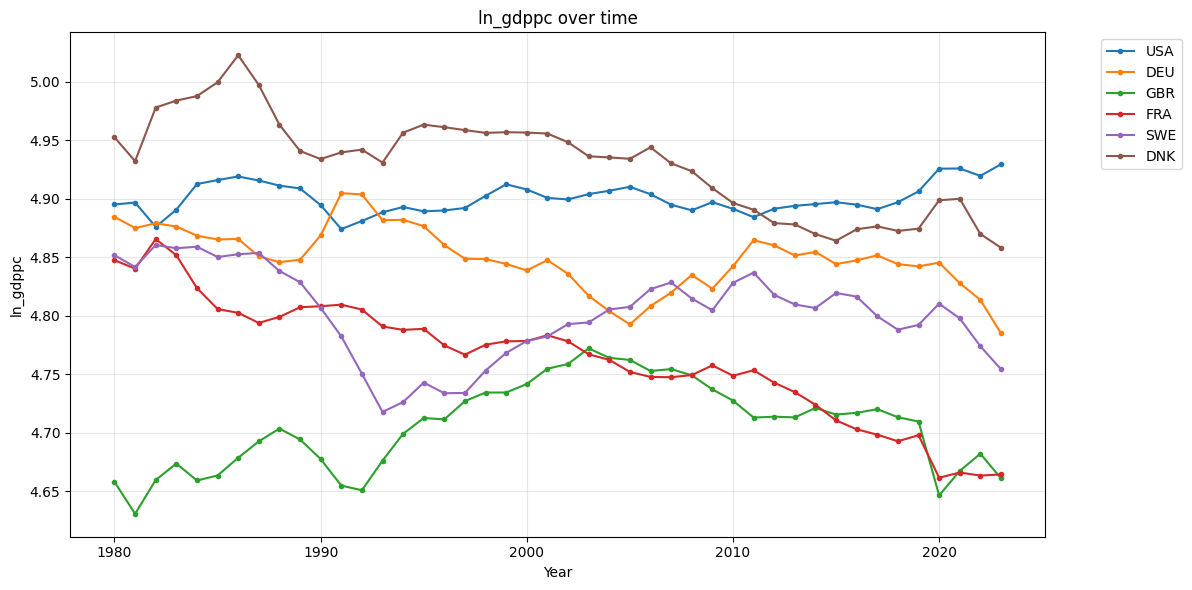

In [11]:
from clean import plot_time_series, plot_correlation_matrix
import matplotlib.pyplot as plt

# Plot GDP over time for selected countries
plot_time_series(
    master,
    'ln_gdppc',
    countries=['USA', 'DEU', 'GBR', 'FRA', 'SWE', 'DNK']
)

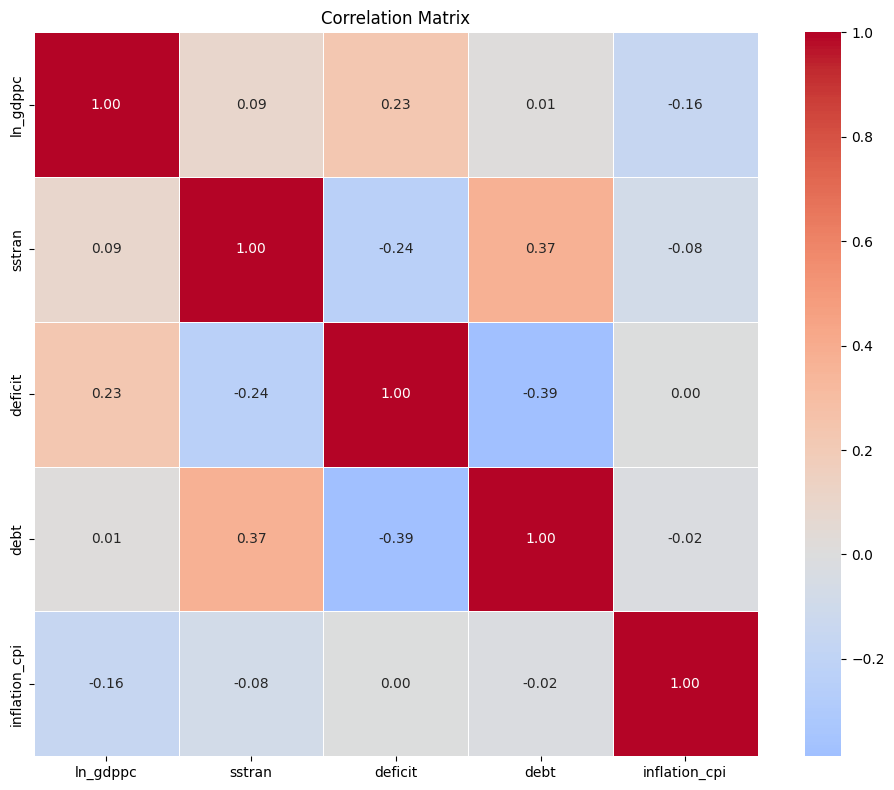

In [12]:
# Correlation heatmap
plot_correlation_matrix(
    master,
    variables=['ln_gdppc', 'sstran', 'deficit', 'debt', 'inflation_cpi']
)

### Average Social Security Transfers Across All Countries


✅ Saved figure to: C:\Users\Anton\economics-of-the-welfare-state\outputs\figures\sstran_average.png


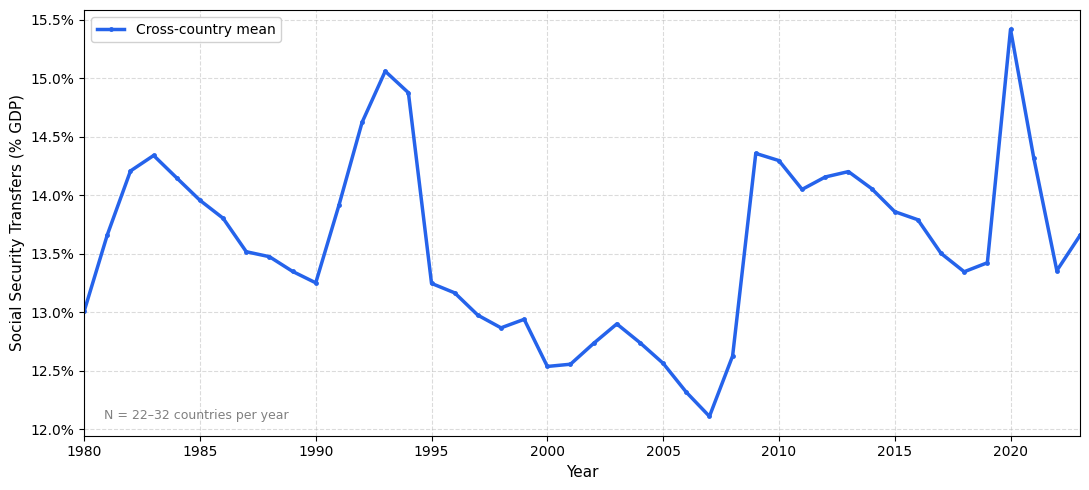


Period average: 13.57% of GDP
Peak year:      2020 (15.42%)
Trough year:    2007 (12.11%)


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Compute cross-country mean per year ─────────────────────────────────────────
agg = master.dropna(subset=["sstran"]).copy()

# Ensure numeric types
agg["year"] = pd.to_numeric(agg["year"], errors="coerce")
agg["sstran"] = pd.to_numeric(agg["sstran"], errors="coerce")
agg = agg.dropna(subset=["year", "sstran"])

# Group and calculate mean
agg = (
    agg.groupby("year")["sstran"]
    .agg(mean="mean", n="count")
    .reset_index()
)

# Extract as raw float arrays for matplotlib
x_year = np.array(agg["year"], dtype=float)
y_mean = np.array(agg["mean"], dtype=float)

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# Mean line
ax.plot(
    x_year, y_mean,
    color="#2563EB", linewidth=2.5,
    marker="o", markersize=3.5, markeredgewidth=0,
    label="Cross-country mean"
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Social Security Transfers (% GDP)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(framealpha=0.9, loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.45)
ax.set_xlim(x_year.min(), x_year.max())

# Annotate country count
n_min, n_max = int(agg["n"].min()), int(agg["n"].max())
ax.annotate(
    f"N = {n_min}–{n_max} countries per year",
    xy=(0.02, 0.04), xycoords="axes fraction",
    fontsize=9, color="grey"
)

plt.tight_layout()

# ── Save export ──────────────────────────────────────────────────────
from pathlib import Path

# Create outputs/figures director if it doesn't exist
out_dir = Path(REPO_ROOT) / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

# Save high-res for publications
out_path_png = out_dir / "sstran_average.png"
out_path_pdf = out_dir / "sstran_average.pdf"

fig.savefig(out_path_png, dpi=300, bbox_inches="tight")
fig.savefig(out_path_pdf, bbox_inches="tight")

print(f"\n✅ Saved figure to: {out_path_png}")

plt.show()

# Quick numeric summary
print(f"\nPeriod average: {agg['mean'].mean():.2f}% of GDP")
print(f"Peak year:      {int(agg.loc[agg['mean'].idxmax(), 'year'])} ({agg['mean'].max():.2f}%)")
print(f"Trough year:    {int(agg.loc[agg['mean'].idxmin(), 'year'])} ({agg['mean'].min():.2f}%)")

### Average KOF Globalization Indices Across All Countries


✅ Saved figure to: C:\Users\Anton\economics-of-the-welfare-state\outputs\figures\kof_indices_average.png


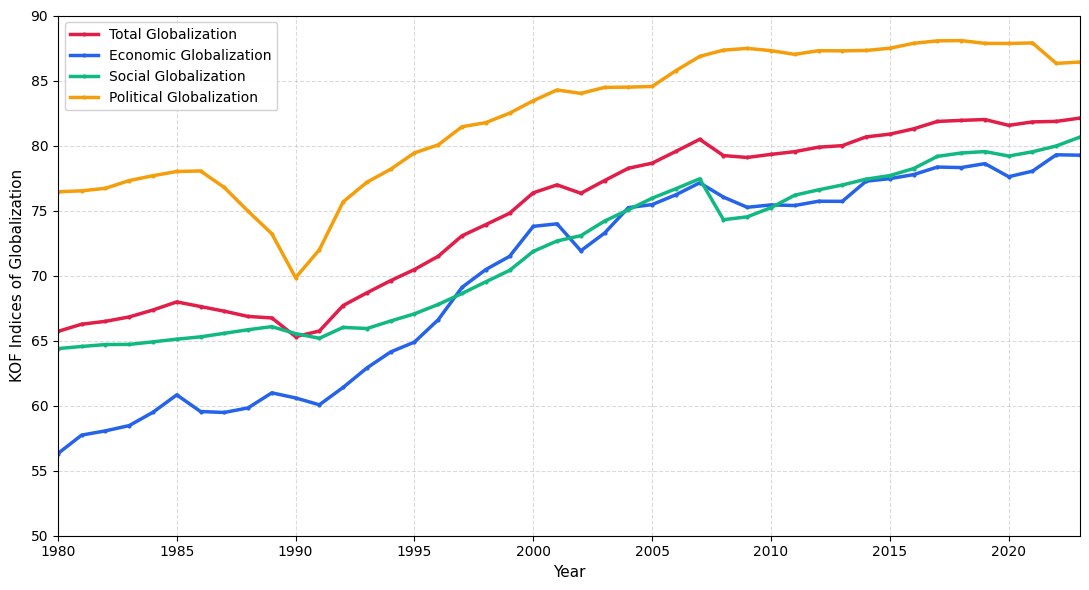


Overall Globalization (KOFGI) trend: 65.7 (1980) → 82.1 (2023)


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from pathlib import Path

# ── Compute cross-country mean for KOF indices ───────────────────────
indices = ["KOFGI", "KOFEcGI", "KOFSoGI", "KOFPoGI"]
labels = {
    "KOFGI": "Total Globalization",
    "KOFEcGI": "Economic Globalization",
    "KOFSoGI": "Social Globalization",
    "KOFPoGI": "Political Globalization"
}
colors = {
    "KOFGI": "#E11D48",    # Red
    "KOFEcGI": "#2563EB",  # Blue
    "KOFSoGI": "#10B981",  # Green
    "KOFPoGI": "#F59E0B"   # Orange
}

# Ensure numeric types and drop NaNs
kof_data = master[["year", "iso3"] + indices].copy()
for col in ["year"] + indices:
    kof_data[col] = pd.to_numeric(kof_data[col], errors="coerce")

# Calculate yearly mean
agg_kof = (
    kof_data.dropna(subset=indices, how="all")
    .groupby("year")[indices]
    .mean()
    .reset_index()
)

# Extract x_year as raw float array
x_year = np.array(agg_kof["year"], dtype=float)

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

for idx in indices:
    y_values = np.array(agg_kof[idx], dtype=float)
    ax.plot(
        x_year, y_values,
        label=labels[idx], color=colors[idx],
        linewidth=2.5, marker="o", markersize=3, markeredgewidth=0
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("KOF Indices of Globalization", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.legend(framealpha=0.9, loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.45)
ax.set_xlim(x_year.min(), x_year.max())
ax.set_ylim(50, 90) # KOF indices are 0-100

plt.tight_layout()

# ── Save export ──────────────────────────────────────────────────────
out_dir = Path(REPO_ROOT) / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_path_png = out_dir / "kof_indices_average.png"
out_path_pdf = out_dir / "kof_indices_average.pdf"

fig.savefig(out_path_png, dpi=300, bbox_inches="tight")
fig.savefig(out_path_pdf, bbox_inches="tight")

print(f"\n✅ Saved figure to: {out_path_png}")

plt.show()

# Quick summary
print(f"\nOverall Globalization (KOFGI) trend: {agg_kof['KOFGI'].iloc[0]:.1f} (1980) \u2192 {agg_kof['KOFGI'].iloc[-1]:.1f} ({int(x_year[-1])})")

## Part 7: Filter by Country Groups

In [15]:
from clean import filter_by_region, list_regions

# See available regions
list_regions()

COUNTRY GROUPS

WESTERN EUROPE (17 countries):
  AUT, BEL, CHE, DEU, DNK, ESP, FIN, FRA, GBR, GRC, IRL, ITA, LUX, NLD, NOR, PRT, SWE

EASTERN EUROPE (9 countries):
  BGR, CZE, EST, HUN, LTU, LVA, POL, SVK, SVN

ANGLO (5 countries):
  AUS, CAN, GBR, NZL, USA

NORDIC (5 countries):
  DNK, FIN, ISL, NOR, SWE

EU FOUNDERS (6 countries):
  BEL, DEU, FRA, ITA, LUX, NLD

POST COMMUNIST (9 countries):
  BGR, CZE, EST, HUN, LTU, LVA, POL, SVK, SVN



## Part 8: Robustness Checks

### Robustness Checks: Testing the Stability of Our Results

A single regression result is never sufficient for credible empirical research. **Robustness checks** test whether our findings hold under alternative specifications and data treatments:

| Check | What it does | Why it matters |
|---|---|---|
| **Drop outliers** | Removes observations >3 standard deviations from the mean | Extreme values (e.g., hyperinflation) can drive results |
| **Winsorize** | Caps extreme values at the 1st/99th percentile instead of removing them | Less aggressive than dropping; preserves sample size |
| **Pre-2008** | Restricts sample to years before the Global Financial Crisis | Tests whether results are driven by the crisis period |
| **Post-2008** | Restricts sample to years after the crisis | Tests whether the relationship changed structurally |

If our core finding (the sign and significance of the globalisation coefficient) survives across all these specifications, we can be more confident that it reflects a genuine empirical relationship rather than an artefact of a particular sample or specification choice.

In [16]:
from clean.robustness import run_robustness_checks, compare_robustness_results
from statsmodels.formula.api import ols

# Run model with automated robustness checks
robust_results = run_robustness_checks(
    master_with_lags,
    'sstran ~ ln_gdppc + deficit + ln_gdppc_lag1',
    ols,
    checks=['drop_outliers', 'winsorize', 'pre_2008', 'post_2008']
)

Running baseline model...
Running robustness check: drop_outliers
✅ drop_outliers: 1196 observations
Running robustness check: winsorize
✅ winsorize: 1408 observations
Running robustness check: pre_2008
✅ pre_2008: 896 observations
Running robustness check: post_2008
✅ post_2008: 512 observations


In [17]:
# Compare coefficients across specifications
comparison = compare_robustness_results(robust_results, variable='ln_gdppc')


ROBUSTNESS CHECK COMPARISON

Variable: ln_gdppc

specification  coefficient  std_error      p_value  n_obs
     baseline   -20.771338   4.195593 8.431573e-07   1222
drop_outliers   -22.621390   4.482078 5.184150e-07   1196
    winsorize   -21.998059   4.326829 4.272402e-07   1222
     pre_2008    -8.905989   5.837300 1.275310e-01    711
    post_2008   -30.067724   6.011682 7.851418e-07    511


## Part 9: Publication Table

In [18]:
from clean import create_publication_table

# Create publication-ready table
pub_table = create_publication_table(
    list(robust_results.values()),
    model_names=['Baseline', 'No Outliers', 'Winsorized', 'Pre-2008', 'Post-2008'],
    output_format='text'
)

print(pub_table)

⚠️  stargazer package recommended: pip install stargazer

REGRESSION RESULTS
Variable                 Baseline  No Outliers   Winsorized     Pre-2008    Post-2008
------------------------------------------------------------
Intercept                9.376***     9.665***     9.133***     4.822***    15.410***
                          (1.381)      (1.496)      (1.388)      (1.798)      (2.172)
deficit                 -0.194***    -0.221***    -0.212***    -0.224***    -0.160***
                          (0.024)      (0.028)      (0.026)      (0.032)      (0.035)
ln_gdppc               -20.771***   -22.621***   -21.998***       -8.906   -30.068***
                          (4.196)      (4.482)      (4.327)      (5.837)      (6.012)
ln_gdppc_lag1           21.567***    23.337***    22.835***      10.602*    29.650***
                          (4.105)      (4.373)      (4.235)      (5.692)      (5.917)
------------------------------------------------------------
N                          

## Part 10: Generate Methods Section

In [19]:
from clean import generate_methods_section

# Auto-generate data section for paper
methods = generate_methods_section(
    master,
    output_path=REPO_ROOT / "paper" / "methods.md"
)

print("Methods section generated! Preview:")
print(methods[:500] + "...")

✅ Methods section saved to: C:\Users\Anton\economics-of-the-welfare-state\paper\methods.md
Methods section generated! Preview:
# Data and Methods

## Data Sources

This study utilizes panel data from multiple sources:


**CPDS:**
- *Social security transfers* (`sstran`)
- *Government deficit* (`deficit`)
- *Government debt* (`debt`)

**World Bank:**
- *Log population* (`ln_population`)
- *Inflation rate* (`inflation_cpi`)
- *Age dependency ratio* (`dependency_ratio`)

**World Bank / OECD:**
- *Log GDP per capita* (`ln_gdppc`)

## Sample

The analysis covers **32 countries** over the period **1980–2023**, yielding **1,40...


## Part 11: Export to R/Stata

### Exporting for Other Statistical Software

Academic research teams often use multiple software packages. To ensure our cleaned dataset is accessible to all collaborators, we export:

- **R script** (`analysis.R`): Auto-generated with `library()` calls, panel data setup (`pdata.frame`), and sample model specifications using `fixest` and `plm`.
- **Stata do-file** (`analysis.do`): Auto-generated with `xtset`, variable labels, and sample `xtreg` commands.

These scripts serve as starting points — researchers can modify the model specifications while using the same cleaned data, ensuring reproducibility across teams and software.

In [20]:
from clean.export import export_to_r, export_to_stata_script

# Generate R script with pre-configured models
export_to_r(
    master_with_lags,
    REPO_ROOT / 'analysis' / 'analysis.R',
    include_packages=['fixest', 'plm', 'did']
)

# Generate Stata script
export_to_stata_script(
    master_with_lags,
    REPO_ROOT / 'analysis' / 'analysis.do'
)

✅ R script saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\analysis.R
✅ Data saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\master.csv

To use:
  1. Open R or RStudio
  2. Run: source('analysis.R')
✅ Stata script saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\analysis.do
✅ Data saved to: C:\Users\Anton\economics-of-the-welfare-state\analysis\master.dta


### Table 8: Correlation Matrix

In [21]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# ── Prepare variables with lags ──────────────────────────────────────
# Sort by country and year to properly compute lags
df_corr = master.sort_values(["iso3", "year"]).copy()

# Variables to lag (all except the main dependent variable)
lag_vars = {
    "KOFGI": "OG (t-1)",
    "KOFEcGI": "EG (t-1)",
    "KOFPoGI": "PG (t-1)",
    "KOFSoGI": "SG (t-1)",
    "ln_gdppc": "GDPpc (t-1)",
    "inflation_cpi": "Inf. (t-1)",
    "deficit": "Deficit (t-1)",
    "debt": "Gov. debt (t-1)",
    "ln_population": "Log pop. (t-1)",
    "dependency_ratio": "Dep. (t-1)"
}

# Apply 1-year lag within each country group
for col, new_name in lag_vars.items():
    if col in df_corr.columns:
        df_corr[new_name] = df_corr.groupby("iso3")[col].shift(1)

# Main dependent variable
df_corr["WS"] = df_corr["sstran"]

# Order of columns for the table per request
col_order = ["WS"] + list(lag_vars.values())

# Keep only necessary columns
corr_data = df_corr[col_order]

# ── Calculate Correlation and P-values ───────────────────────────────
def calculate_pvalues(df):
    df_cols = pd.DataFrame(columns=df.columns)
    pvalues = df_cols.transpose().join(df_cols, how="outer")
    for r in df.columns:
        for c in df.columns:
            if r == c:
                pvalues.loc[r, c] = 0.0
            else:
                # Drop pairwise NaNs to compute valid scipy pearsonr
                mask = df[r].notna() & df[c].notna()
                if mask.sum() > 2: # need at least 3 points
                    pvalues.loc[r, c] = stats.pearsonr(df[r][mask], df[c][mask])[1]
                else:
                    pvalues.loc[r, c] = np.nan
    return pvalues

# Compute pearson correlation matrix
corr_matrix = corr_data.corr(method="pearson")
# Compute significance matrix
pval_matrix = calculate_pvalues(corr_data)

# Format cells with significance stars (*** 1%, ** 5%, * 10%)
def format_with_stars(val, pval):
    if pd.isna(val) or pd.isna(pval):
        return ""
    
    val_str = f"{val:.2f}"
    if pval < 0.01:
        return val_str + "***"
    elif pval < 0.05:
        return val_str + "**"
    elif pval < 0.10:
        return val_str + "*"
    else:
        return val_str

# Create formatted lower-triangle table
formatted_table = pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns)
for r in corr_matrix.index:
    for c in corr_matrix.columns:
        idx_r = list(corr_matrix.index).index(r)
        idx_c = list(corr_matrix.columns).index(c)
        
        if idx_r == idx_c:
            formatted_table.loc[r, c] = "1.00"
        elif idx_c > idx_r:
            formatted_table.loc[r, c] = "" # Upper triangle
        else:
            formatted_table.loc[r, c] = format_with_stars(corr_matrix.loc[r, c], pval_matrix.loc[r, c])

# ── Save and Display ──────────────────────────────────────────────────
out_dir = Path(REPO_ROOT) / "outputs" / "tables"
out_dir.mkdir(parents=True, exist_ok=True)

# Save to CSV
out_path_csv = out_dir / "correlation_matrix.csv"
formatted_table.to_csv(out_path_csv)
print(f"✅ Correlation matrix saved to CSV: {out_path_csv}")

# Save to LaTeX
out_path_tex = out_dir / "correlation_matrix.tex"
with open(out_path_tex, 'w', encoding='utf-8') as f:
    f.write(formatted_table.to_latex(
        caption="Correlation Matrix",
        label="tab:correlation_matrix",
        column_format="l" + "c" * len(formatted_table.columns),
        position="htbp"
    ))
print(f"✅ Correlation matrix saved to LaTeX: {out_path_tex}\n")

print("Table 8: Correlation matrix")
display(formatted_table)

print("\nNotes: OG: Overall Globalization, EG: Economic, PG: Political, SG: Social")
print("***, **, * denote statistical significance at 1, 5 and 10%, respectively")


✅ Correlation matrix saved to CSV: C:\Users\Anton\economics-of-the-welfare-state\outputs\tables\correlation_matrix.csv


✅ Correlation matrix saved to LaTeX: C:\Users\Anton\economics-of-the-welfare-state\outputs\tables\correlation_matrix.tex

Table 8: Correlation matrix


,WS,OG (t-1),EG (t-1),PG (t-1),SG (t-1),GDPpc (t-1),Inf. (t-1),Deficit (t-1),Gov. debt (t-1),Log pop. (t-1),Dep. (t-1)
WS,1.00,,,,,,,,,,
OG (t-1),0.32***,1.00,,,,,,,,,
EG (t-1),0.23***,0.85***,1.00,,,,,,,,
PG (t-1),0.43***,0.77***,0.39***,1.00,,,,,,,
SG (t-1),-0.01,0.81***,0.73***,0.38***,1.00,,,,,,
GDPpc (t-1),0.09***,0.41***,0.28***,0.23***,0.54***,1.00,,,,,
Inf. (t-1),-0.07**,-0.25***,-0.15***,-0.22***,-0.25***,-0.16***,1.00,,,,
Deficit (t-1),-0.21***,0.21***,0.27***,-0.05*,0.35***,0.23***,0.00,1.00,,,
Gov. debt (t-1),0.35***,0.21***,0.02,0.39***,0.02,0.02,-0.02,-0.39***,1.00,,
Log pop. (t-1),0.15***,0.08***,-0.28***,0.58***,-0.22***,-0.04,-0.07**,-0.30***,0.39***,1.00,



Notes: OG: Overall Globalization, EG: Economic, PG: Political, SG: Social
***, **, * denote statistical significance at 1, 5 and 10%, respectively


# Part 7: Baseline model

# Part 8: Heterogeneity across Welfare Regimes
Analyzing how the impact of globalization on social security transfers varies by welfare regime.

### Baseline Regressions: The Average Effect of Globalisation

Before examining whether the impact of globalisation depends on the welfare regime, we first estimate the **baseline effect** across all countries in our sample. These models provide the "average" relationship between globalisation and social security transfers, controlling for economic and demographic factors but *without* interaction terms.

We estimate four baseline models, one for each dimension of the KOF Globalisation Index. This allows us to see if, on average, more globalised countries (or those becoming more globalised) tend to spend more or less on social transfers.

In [23]:
from analysis.regression_utils import prepare_regression_data, run_panel_ols, plot_coefficients, LATEX_LABEL_MAP
from linearmodels.panel import compare

baseline_results = {}
indices = config['indices']
lagged_ctrls = [f"{v}_lag1" for v in config['controls']]

for idx_name in indices:
    reg_data = create_lags(master_regimes, [idx_name] + config['controls'], lags=config['lags'])
    g_var = f"{idx_name}_lag1"
    
    ols_data, exog_vars = prepare_regression_data(reg_data, config['dependent_var'], g_var, lagged_ctrls, interactions=False)
    baseline_results[idx_name] = run_panel_ols(ols_data, config['dependent_var'], exog_vars)
    
    plot_coefficients(baseline_results[idx_name], title=f"Baseline: {idx_name} on Social Spending")

baseline_comparison = compare(baseline_results, stars=True)
display(baseline_comparison)


✅ Created KOFGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1


✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1
✅ Created KOFEcGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1


✅ Created KOFSoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1


✅ Created KOFPoGI_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1


✅ Baseline models estimated.
✅ Baseline table saved to: ../outputs/tables/baseline_regression_table.tex


,KOFGI,KOFEcGI,KOFSoGI,KOFPoGI
Dep. Variable,sstran,sstran,sstran,sstran
Estimator,PanelOLS,PanelOLS,PanelOLS,PanelOLS
No. Observations,996,996,996,996
Cov. Est.,Clustered,Clustered,Clustered,Clustered
R-squared,0.3583,0.3523,0.3706,0.3579
R-Squared (Within),0.3220,0.2747,0.3174,0.3120
R-Squared (Between),-5.4414,-10.053,-4.4064,-7.3221
R-Squared (Overall),-3.9675,-7.4364,-3.2069,-5.3812
F-statistic,73.776,71.867,77.807,73.664
P-value (F-stat),0.0000,0.0000,0.0000,0.0000


### Panel Fixed Effects Regression with Welfare Regime Interactions

This is the core econometric model of our analysis. We estimate a **two-way fixed effects (TWFE)** model:

$$sstran_{it} = \alpha_i + \gamma_t + \beta_1 \cdot Glob_{i,t-1} + \beta_2 \cdot (Glob_{i,t-1} \times Conservative_i) + \ldots + \mathbf{X}_{i,t-1}'\delta + \varepsilon_{it}$$

**Model components explained:**
- **$\alpha_i$ (Entity fixed effects):** Absorb all *time-invariant* differences between countries (geography, legal tradition, culture). This means we're estimating *within-country* variation only.
- **$\gamma_t$ (Time fixed effects):** Absorb all *country-invariant* shocks that affect all countries in a given year (e.g., global recessions, oil price shocks).
- **$\beta_1$ (Base globalisation effect):** The marginal effect of globalisation for the **reference group** (Social Democrat regimes).
- **Interaction terms ($\beta_2, \ldots, \beta_5$):** How much the globalisation effect *differs* for each regime relative to Social Democrats. The total effect for, say, Liberal regimes is $\beta_1 + \beta_4$.
- **Controls ($\mathbf{X}_{i,t-1}$):** Lagged GDP per capita, inflation, fiscal deficit, debt, population, and dependency ratio — all measured at $t-1$ to avoid simultaneity.
- **Clustered standard errors:** We cluster at the country level to account for serial correlation within countries over time, producing robust inference.

> **Interpretation:** A positive interaction coefficient (e.g., $\beta_{conservative} > 0$) means that globalisation increases social spending *more* in Conservative regimes than in Social Democrat ones.

### Creating Lag Variables for Dynamic Models

In panel data econometrics, we often use **lagged** (past-period) values of independent variables rather than contemporaneous ones. This serves two purposes:

1. **Temporal ordering / causality:** If we want to argue that globalisation *causes* changes in welfare spending, we need globalisation measured *before* the spending — i.e., `KOFGIₜ₋₁ → sstranₜ`. Using contemporaneous values (`KOFGIₜ → sstranₜ`) makes it impossible to distinguish cause from effect.

2. **Reducing simultaneity bias:** When two variables are determined at the same time (e.g., government spending and GDP), OLS estimates are biased. Lagging the independent variable breaks this simultaneity.

The `create_lags()` function generates new columns (e.g., `ln_gdppc_lag1`) by shifting each variable one period backward *within each country*, ensuring we don't accidentally use Country A's past value for Country B.

We also check **panel balance** here — whether all countries have the same number of time periods. An unbalanced panel is common in practice and is handled correctly by the fixed-effects estimator.

## Part 8: Feedback Regressions (Globalization as Dependent Variable)

In this section, we investigate the "feedback" effect: does the size of the welfare state (measured by social security transfers) influence the level of globalization? 

We estimate four models where the dependent variables are the Overall, Economic, Social, and Political globalization indices. The primary independent variable is the lagged level of social security transfers (`sstran_lag1`).

### Feedback Regressions: Does Welfare Spending Affect Globalisation?

A common criticism of globalisation-welfare research is the possibility of **reverse causality**: perhaps it's not globalisation that drives welfare spending, but welfare spending that influences a country's degree of globalisation.

For example:
- Countries with generous welfare states may be *more open* to trade because their citizens feel protected against economic shocks (the **compensation hypothesis**).
- Alternatively, high social spending may *reduce* economic competitiveness, leading to *less* economic openness.

To investigate this, we **reverse the model**: now the globalisation indices are the *dependent* variables, and `sstran_lag1` (lagged social spending) is the key independent variable.

$$Glob_{it} = \alpha_i + \gamma_t + \phi \cdot sstran_{i,t-1} + \mathbf{X}_{i,t-1}'\delta + \varepsilon_{it}$$

If $\phi$ is statistically significant, it suggests a feedback loop exists — meaning the relationship runs in *both* directions and a more sophisticated model (e.g., a system of simultaneous equations or GMM) may be warranted.

> **Note:** This test does not conclusively prove or disprove causality — it is a suggestive diagnostic. True causal identification would require instrumental variables or a natural experiment.

In [29]:
# ── Feedback Regressions: Globalization = f(sstran_{t-1}, controls_{t-1}) ──
from linearmodels.panel import compare
import os
from analysis.regression_utils import prepare_regression_data, run_panel_ols, LATEX_LABEL_MAP

# 1. Define variables
dv_indices = ["KOFGI", "KOFEcGI", "KOFSoGI", "KOFPoGI"]
ctrl_vars = ["ln_gdppc", "inflation_cpi", "deficit", "debt", "ln_population", "dependency_ratio"]
iv_var = "sstran"
feedback_models = {}

for dv_name in dv_indices:
    # Create lags for sstran and all controls
    all_needed_vars = [dv_name, iv_var] + ctrl_vars
    reg_data = create_lags(master_regimes, all_needed_vars, lags=[1])
    
    dv_var = dv_name # Dependent variable is the current level
    iv_lagged = f"{iv_var}_lag1"
    ctrls_lagged = [f"{v}_lag1" for v in ctrl_vars]
    
    # Use regression utils (no interactions for feedback)
    ols_data, exog_vars = prepare_regression_data(reg_data, dv_var, iv_lagged, ctrls_lagged, interactions=False)
    feedback_models[dv_name] = run_panel_ols(ols_data, dv_var, exog_vars)

# 2. Compare models with stars
feedback_comparison = compare(feedback_models, stars=True)
print("✅ Feedback regressions estimated with significance stars.")

# 3. Export to LaTeX
output_file = "../outputs/tables/feedback_regression_table.tex"
os.makedirs(os.path.dirname(output_file), exist_ok=True)

latex_str = feedback_comparison.summary.as_latex()
for old, new in LATEX_LABEL_MAP.items():
    latex_str = latex_str.replace(old, new)

with open(output_file, "w", encoding="utf-8") as f:
    f.write(latex_str)

print(f"✅ Feedback regression table saved to: {output_file}")
display(feedback_comparison)


✅ Created KOFGI_lag1


✅ Created sstran_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1


✅ Created KOFEcGI_lag1
✅ Created sstran_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1
✅ Created KOFSoGI_lag1
✅ Created sstran_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1


✅ Created KOFPoGI_lag1
✅ Created sstran_lag1
✅ Created ln_gdppc_lag1
✅ Created inflation_cpi_lag1
✅ Created deficit_lag1
✅ Created debt_lag1
✅ Created ln_population_lag1
✅ Created dependency_ratio_lag1


✅ Feedback regressions estimated with significance stars.
✅ Feedback regression table saved to: ../outputs/tables/feedback_regression_table.tex


,KOFGI,KOFEcGI,KOFSoGI,KOFPoGI
Dep. Variable,KOFGI,KOFEcGI,KOFSoGI,KOFPoGI
Estimator,PanelOLS,PanelOLS,PanelOLS,PanelOLS
No. Observations,996,996,996,996
Cov. Est.,Clustered,Clustered,Clustered,Clustered
R-squared,0.5138,0.3490,0.3607,0.2741
R-Squared (Within),0.0560,0.0062,-0.1682,0.2854
R-Squared (Between),-16.385,-14.048,-14.694,-1.2916
R-Squared (Overall),-10.143,-9.9411,-8.2948,-1.0910
F-statistic,139.64,70.850,74.547,49.905
P-value (F-stat),0.0000,0.0000,0.0000,0.0000
